In [1]:
import pandas as pd
from io import StringIO
from azure.storage.blob import BlobServiceClient, BlobPrefix, BlobProperties
import sys # Include sys for controlled exit on errors

# --- Azure Blob Storage Configuration ---
# Configures connection details for Azure Blob Storage.
storage_account_name = "germangenergyml3460062973"
container_name = "azureml-blobstore-1316afd2-83bb-49ff-90cd-6647302e0bb4"
base_data_path_in_blob = "UI/2025-07-29_002810_UTC/RawData/"

# Defines the connection string for Azure Blob Storage authentication.
connection_string = "Strng key"

# --- Azure Blob Storage Connection and Client Initialization ---
# Attempts to establish connection to Azure Blob Storage and initialize clients.
try:
    blob_service_client = BlobServiceClient.from_connection_string(connection_string)
    # Initialize container_client to interact with the specified container.
    container_client = blob_service_client.get_container_client(container_name)
    print(f"Successfully connected to container '{container_name}'.")
except Exception as e:
    print(f"Error connecting to Azure Blob Storage or initializing container client: {e}")
    sys.exit("Exiting due to Azure connection error.") # Exit if essential connection fails

Successfully connected to container 'azureml-blobstore-1316afd2-83bb-49ff-90cd-6647302e0bb4'.


In [2]:
# --- Azure Blob Storage Content Listing ---
# Lists files and folders within the specified base data path in the Azure Blob container.
try:
    # Ensure 'container_client' is defined from BlobServiceClient for this to work.
    # Example: container_client = blob_service_client.get_container_client(container_name)
    blobs_and_prefixes = container_client.walk_blobs(name_starts_with=base_data_path_in_blob, delimiter='/')

    found_items = False
    for item in blobs_and_prefixes:
        if isinstance(item, BlobPrefix):
            folder_name = item.name[len(base_data_path_in_blob):].strip('/')
            if folder_name:
                print(f"- {folder_name}/ (Folder)")
                found_items = True
        elif isinstance(item, BlobProperties):
            file_name = item.name[len(base_data_path_in_blob):]
            if file_name:
                print(f"- {file_name} (File)")
                found_items = True

    if not found_items:
        print(f"No files or folders found at '{base_data_path_in_blob}'.")
        print("Please double-check the 'base_data_path_in_blob' and 'container_name'.")

except Exception as e:
    print(f"Error listing blobs: {e}")

- airtemp/ (Folder)
- cloudiness/ (Folder)
- precipitation/ (Folder)
- solar/ (Folder)
- wind/ (Folder)
- Actual_generation_202301010000_202507300000_Quarterhour (1).csv (File)


In [3]:
# --- Data Loading from Azure Blob Storage ---
# Defines the specific CSV file containing actual generation data.
actual_generation_filename = "Actual_generation_202301010000_202507300000_Quarterhour (1).csv"

# Constructs the full path to the blob within the container.
csv_blob_name = f"{base_data_path_in_blob}{actual_generation_filename}"

# Attempts to download the CSV data from Azure Blob Storage and load it into a Pandas DataFrame.
try:
    # Ensure 'container_client' is initialized (e.g., container_client = blob_service_client.get_container_client(container_name))
    blob_client = container_client.get_blob_client(csv_blob_name)
    downloaded_blob_data = blob_client.download_blob().readall().decode('utf-8')

    # Reads the CSV data with specified delimiters, decimal, thousands separators, and NaN values.
    df = pd.read_csv(
        StringIO(downloaded_blob_data),
        delimiter=';',
        decimal='.',
        thousands=',',
        na_values=['-']
    )

    print("\nSuccessfully loaded 'Actual_generation' into DataFrame!")
    print("DataFrame Head (Raw Data Loaded with Correct Parsers):")
    print(df.head())

except Exception as e:
    print(f"Error downloading or reading the CSV file: {e}")
    print("Ensure the CSV file name is correct and the file exists at the specified path.")


Successfully loaded 'Actual_generation' into DataFrame!
DataFrame Head (Raw Data Loaded with Correct Parsers):
             Start date              End date  \
0  Jan 1, 2023 12:00 AM  Jan 1, 2023 12:15 AM   
1  Jan 1, 2023 12:15 AM  Jan 1, 2023 12:30 AM   
2  Jan 1, 2023 12:30 AM  Jan 1, 2023 12:45 AM   
3  Jan 1, 2023 12:45 AM   Jan 1, 2023 1:00 AM   
4   Jan 1, 2023 1:00 AM   Jan 1, 2023 1:15 AM   

   Biomass [MWh] Original resolutions  Hydropower [MWh] Original resolutions  \
0                             1006.25                                 319.75   
1                             1003.50                                 317.25   
2                             1003.00                                 317.00   
3                             1001.50                                 321.25   
4                              997.50                                 314.75   

   Wind offshore [MWh] Original resolutions  \
0                                    684.25   
1                 

In [4]:
# --- Data Type Conversion and Initial Cleaning ---
# Defines columns that should be treated as numerical generation values.
numerical_columns = [
    "Biomass [MWh] Original resolutions",
    "Hydropower [MWh] Original resolutions",
    "Wind offshore [MWh] Original resolutions",
    "Wind onshore [MWh] Original resolutions",
    "Photovoltaics [MWh] Original resolutions",
    "Other renewable [MWh] Original resolutions",
    "Nuclear [MWh] Original resolutions",
    "Lignite [MWh] Original resolutions",
    "Hard coal [MWh] Original resolutions",
    "Fossil gas [MWh] Original resolutions",
    "Hydro pumped storage [MWh] Original resolutions",
    "Other conventional [MWh] Original resolutions"
]

try:
    # Converts specified columns to numeric type, coercing errors to NaN.
    for col in numerical_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Converts 'Start date' and 'End date' columns to datetime objects.
    df['Start date'] = pd.to_datetime(df['Start date'], format='%b %d, %Y %I:%M %p')
    df['End date'] = pd.to_datetime(df['End date'], format='%b %d, %Y %I:%M %p')

    print("\nDataFrame Head (After Final Type Conversion):")
    print(df.head())
    print("\nDataFrame Info (After Final Type Conversion):")
    df.info()
    print("\nNull values after conversion (check for NaNs from '-'s):")
    print(df[numerical_columns].isnull().sum())

except Exception as e:
    print(f"Error during final data type conversion: {e}")
    print("Review column names or data formats if errors persist.")


DataFrame Head (After Final Type Conversion):
           Start date            End date  Biomass [MWh] Original resolutions  \
0 2023-01-01 00:00:00 2023-01-01 00:15:00                             1006.25   
1 2023-01-01 00:15:00 2023-01-01 00:30:00                             1003.50   
2 2023-01-01 00:30:00 2023-01-01 00:45:00                             1003.00   
3 2023-01-01 00:45:00 2023-01-01 01:00:00                             1001.50   
4 2023-01-01 01:00:00 2023-01-01 01:15:00                              997.50   

   Hydropower [MWh] Original resolutions  \
0                                 319.75   
1                                 317.25   
2                                 317.00   
3                                 321.25   
4                                 314.75   

   Wind offshore [MWh] Original resolutions  \
0                                    684.25   
1                                    743.50   
2                                    817.00   
3            

In [5]:
# --- Initial Data Inspection ---
# Displays the dimensions (rows, columns) of the DataFrame.
print("DataFrame Shape (rows, columns):", df.shape)

# Prints the list of all column names in the DataFrame.
print("\nDataFrame Columns:")
print(df.columns.tolist())

# Provides a summary of the DataFrame, including data types and non-null counts.
print("\nNon-Null Counts for All Columns:")
print(df.info())

DataFrame Shape (rows, columns): (90332, 14)

DataFrame Columns:
['Start date', 'End date', 'Biomass [MWh] Original resolutions', 'Hydropower [MWh] Original resolutions', 'Wind offshore [MWh] Original resolutions', 'Wind onshore [MWh] Original resolutions', 'Photovoltaics [MWh] Original resolutions', 'Other renewable [MWh] Original resolutions', 'Nuclear [MWh] Original resolutions', 'Lignite [MWh] Original resolutions', 'Hard coal [MWh] Original resolutions', 'Fossil gas [MWh] Original resolutions', 'Hydro pumped storage [MWh] Original resolutions', 'Other conventional [MWh] Original resolutions']

Non-Null Counts for All Columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90332 entries, 0 to 90331
Data columns (total 14 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Start date                                       90332 non-null  datetime64[n

In [6]:
# --- Descriptive Statistics ---
# Generates and prints summary statistics (e.g., mean, min, max, std) for numerical columns.
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())


Descriptive Statistics for Numerical Columns:
       Biomass [MWh] Original resolutions  \
count                        90235.000000   
mean                          1042.762794   
std                             83.224892   
min                            782.250000   
25%                            978.000000   
50%                           1040.000000   
75%                           1101.250000   
max                           1320.500000   

       Hydropower [MWh] Original resolutions  \
count                           90235.000000   
mean                              453.925680   
std                                98.585287   
min                               249.750000   
25%                               373.500000   
50%                               456.500000   
75%                               520.750000   
max                               815.500000   

       Wind offshore [MWh] Original resolutions  \
count                              90240.000000   
mean        

In [7]:
# --- Data Integrity Checks ---
# Checks for and reports duplicate entries based on 'Start date'.
print(f"\nNumber of duplicate 'Start date' entries: {df['Start date'].duplicated().sum()}")

# Verifies that the time granularity between 'Start date' and 'End date' is consistently 15 minutes.
if not df.empty:
    time_diffs = df['End date'] - df['Start date']
    unique_time_diffs = time_diffs.dt.total_seconds().unique() / 60 # Convert to minutes

    print(f"\nUnique time differences (in minutes) between Start and End dates: {unique_time_diffs}")

    if len(unique_time_diffs) == 1 and unique_time_diffs[0] == 15.0:
        print("Time granularity confirmed as 15 minutes (quarter-hourly).")
    else:
        print("Warning: Time granularity is not consistently 15 minutes or multiple unique durations found.")
else:
    print("DataFrame is empty, cannot check time integrity.")


Number of duplicate 'Start date' entries: 8

Unique time differences (in minutes) between Start and End dates: [   15. -1425.]


In [9]:
# --- Duplicate Entry Analysis ---
# Identifies and displays rows that have duplicate 'Start date' entries.
print("\nInvestigating Duplicate 'Start date' Entries:")
duplicate_start_dates = df[df['Start date'].duplicated(keep=False)].sort_values(by='Start date')
print(duplicate_start_dates)

# Checks for and reports the number of rows that are exact duplicates across all columns.
exact_duplicates = df[df.duplicated(keep=False)].sort_values(by='Start date')
print(f"\nNumber of exact duplicate rows across all columns: {exact_duplicates.shape[0]}")


Investigating Duplicate 'Start date' Entries:
               Start date            End date  \
28900 2023-10-29 02:00:00 2023-10-29 02:15:00   
28904 2023-10-29 02:00:00 2023-10-29 02:15:00   
28901 2023-10-29 02:15:00 2023-10-29 02:30:00   
28905 2023-10-29 02:15:00 2023-10-29 02:30:00   
28902 2023-10-29 02:30:00 2023-10-29 02:45:00   
28906 2023-10-29 02:30:00 2023-10-29 02:45:00   
28903 2023-10-29 02:45:00 2023-10-29 03:00:00   
28907 2023-10-29 02:45:00 2023-10-29 03:00:00   
63844 2024-10-27 02:00:00 2024-10-27 02:15:00   
63848 2024-10-27 02:00:00 2024-10-27 02:15:00   
63845 2024-10-27 02:15:00 2024-10-27 02:30:00   
63849 2024-10-27 02:15:00 2024-10-27 02:30:00   
63846 2024-10-27 02:30:00 2024-10-27 02:45:00   
63850 2024-10-27 02:30:00 2024-10-27 02:45:00   
63847 2024-10-27 02:45:00 2024-10-27 03:00:00   
63851 2024-10-27 02:45:00 2024-10-27 03:00:00   

       Biomass [MWh] Original resolutions  \
28900                             1012.00   
28904                        

In [10]:
# --- Time Consistency Check (Negative Durations) ---
# Calculates the duration in minutes for each record.
df['duration_minutes'] = (df['End date'] - df['Start date']).dt.total_seconds() / 60

# Identifies and displays rows where the 'End date' is earlier than the 'Start date'.
print("\nInvestigating Rows with Negative Time Differences (End Date < Start Date):")
negative_duration_rows = df[df['duration_minutes'] < 0]
print(negative_duration_rows[['Start date', 'End date', 'duration_minutes']])


Investigating Rows with Negative Time Differences (End Date < Start Date):
               Start date            End date  duration_minutes
8071  2023-03-26 01:45:00 2023-03-25 02:00:00           -1425.0
43687 2024-03-31 01:45:00 2024-03-30 02:00:00           -1425.0
78631 2025-03-30 01:45:00 2025-03-29 02:00:00           -1425.0


In [11]:
# --- Data Cleaning: Anomalous Time Entries ---
# Ensures the 'duration_minutes' column exists; calculates it if not present.
if 'duration_minutes' not in df.columns:
    df['duration_minutes'] = (df['End date'] - df['Start date']).dt.total_seconds() / 60

# Identifies and removes rows where the calculated duration is negative.
rows_to_remove_indices = df[df['duration_minutes'] < 0].index
num_removed = len(rows_to_remove_indices)
df.drop(rows_to_remove_indices, inplace=True)

# Removes the temporary 'duration_minutes' column.
df.drop(columns=['duration_minutes'], inplace=True)

print(f"Removed {num_removed} rows with negative time durations.")
print(f"DataFrame shape after cleaning: {df.shape}")

# Re-checks and confirms time granularity after cleaning anomalous entries.
print("\nRe-checking time series integrity after cleaning:")
if not df.empty:
    time_diffs = df['End date'] - df['Start date']
    unique_time_diffs = time_diffs.dt.total_seconds().unique() / 60 # Convert to minutes

    print(f"\nUnique time differences (in minutes) after cleaning: {unique_time_diffs}")

    if len(unique_time_diffs) == 1 and unique_time_diffs[0] == 15.0:
        print("Time granularity confirmed as 15 minutes (quarter-hourly) - negative durations resolved!")
    else:
        print("Warning: Time granularity is still not consistently 15 minutes or multiple unique durations found (this shouldn't happen).")
else:
    print("DataFrame is empty after cleaning.")

# Confirms the number of duplicate 'Start date' entries (expected due to DST).
print(f"\nNumber of duplicate 'Start date' entries (expected for DST): {df['Start date'].duplicated().sum()}")

Removed 3 rows with negative time durations.
DataFrame shape after cleaning: (90329, 14)

Re-checking time series integrity after cleaning:

Unique time differences (in minutes) after cleaning: [15.]
Time granularity confirmed as 15 minutes (quarter-hourly) - negative durations resolved!

Number of duplicate 'Start date' entries (expected for DST): 8


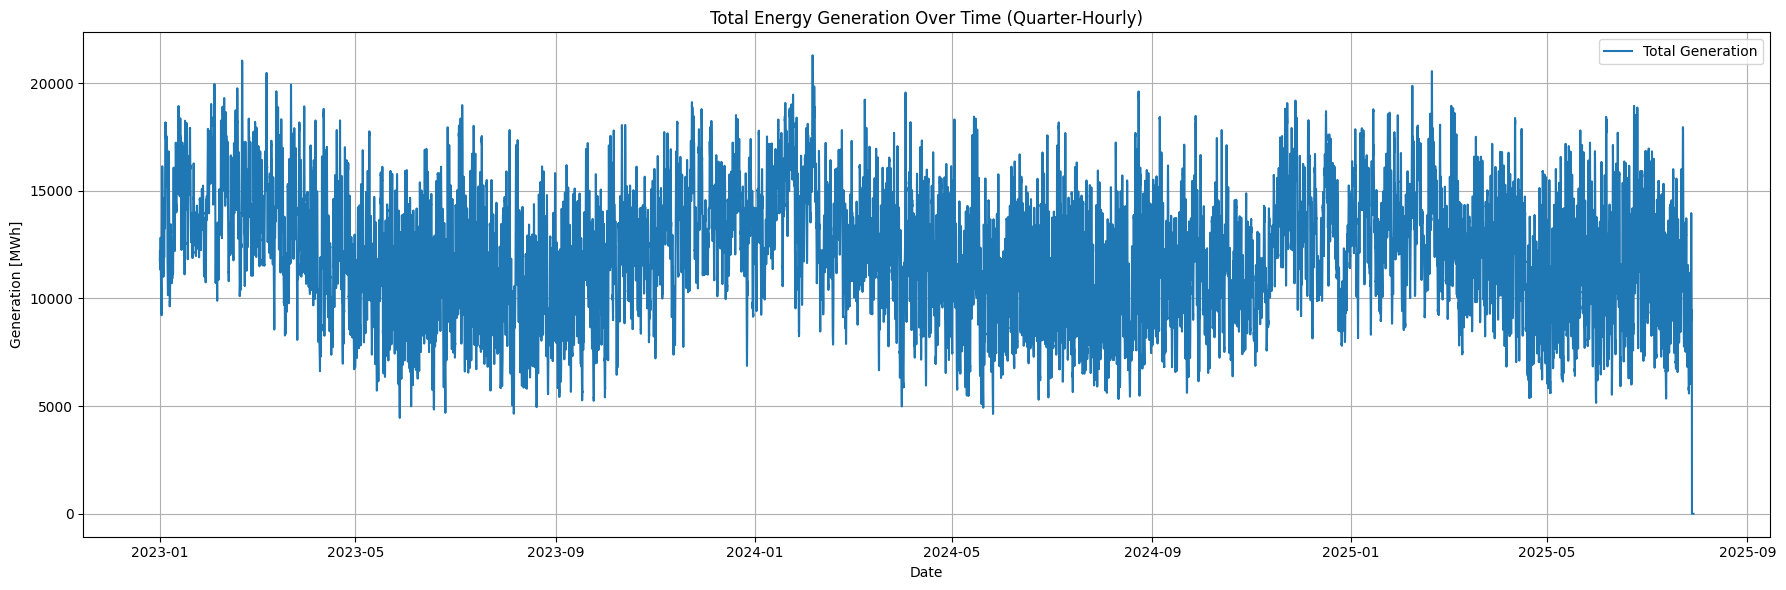

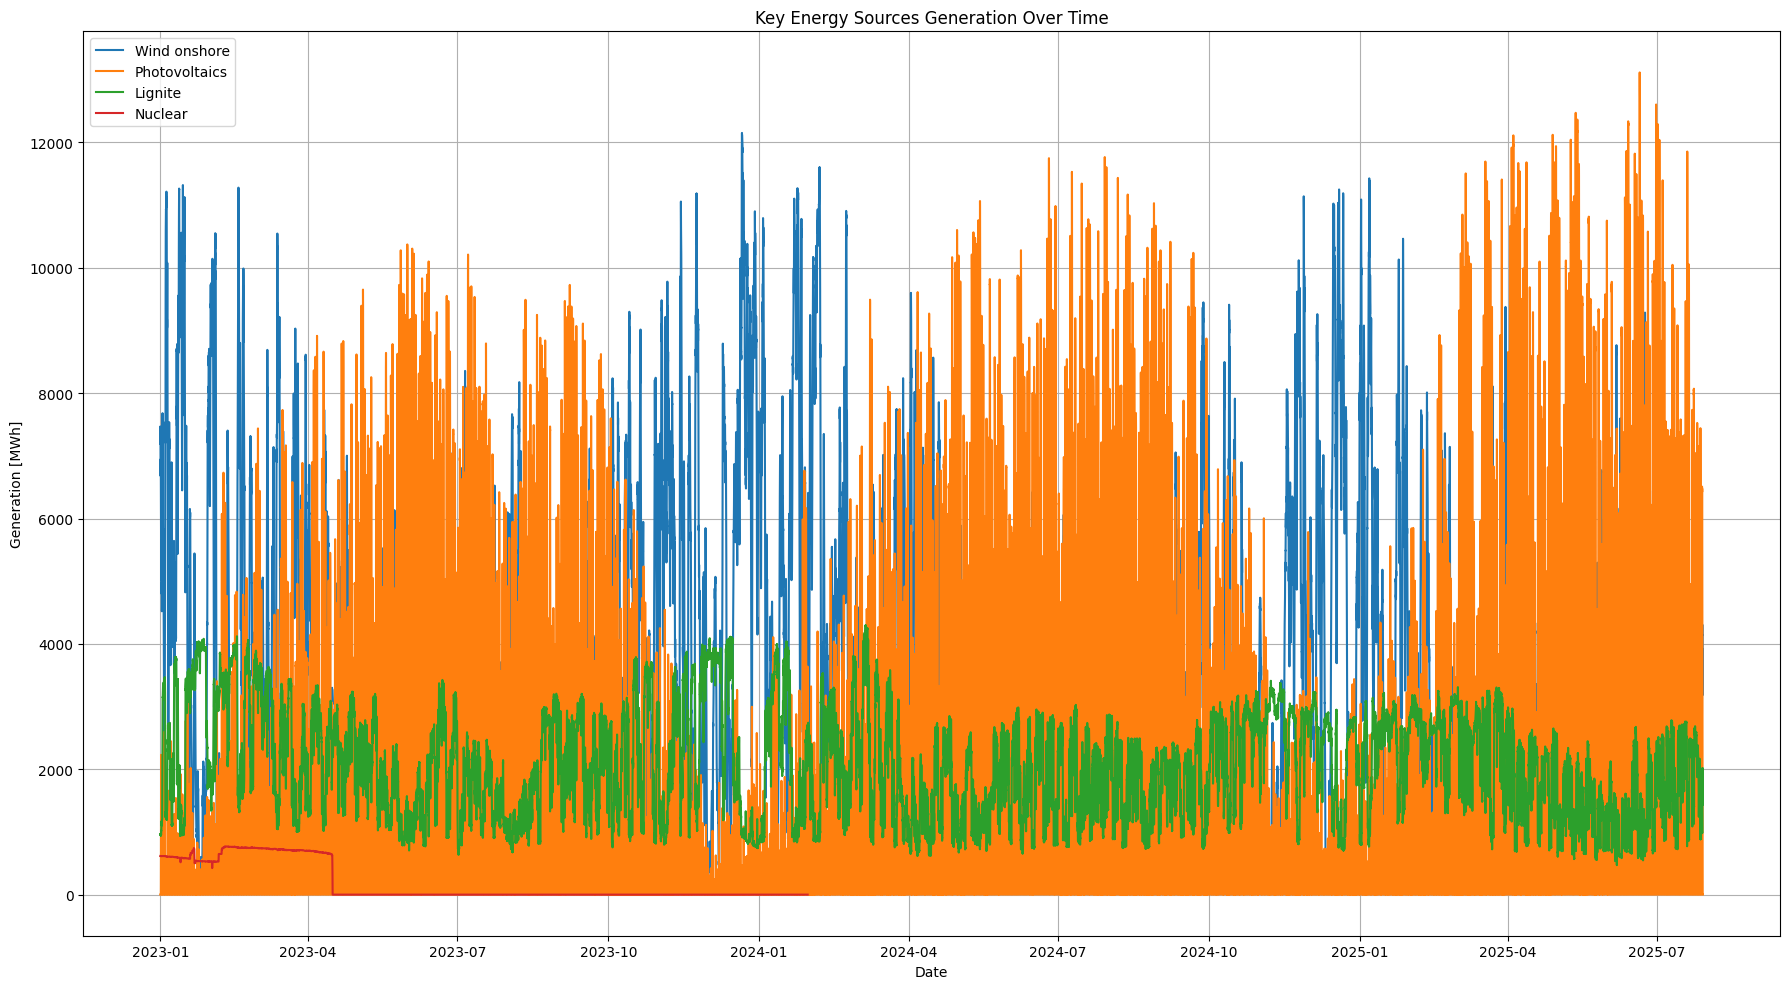

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Exploratory Data Analysis: Overall Trends ---
# Defines the primary generation columns for calculating total generation.
generation_columns = [
    "Biomass [MWh] Original resolutions",
    "Hydropower [MWh] Original resolutions",
    "Wind offshore [MWh] Original resolutions",
    "Wind onshore [MWh] Original resolutions",
    "Photovoltaics [MWh] Original resolutions",
    "Other renewable [MWh] Original resolutions",
    "Nuclear [MWh] Original resolutions",
    "Lignite [MWh] Original resolutions",
    "Hard coal [MWh] Original resolutions",
    "Fossil gas [MWh] Original resolutions"
]

# Calculates the 'Total Generation' by summing the specified generation sources.
df['Total Generation [MWh]'] = df[generation_columns].sum(axis=1)

# Plots the total energy generation over time at a quarter-hourly granularity.
plt.figure(figsize=(18, 6))
plt.plot(df['Start date'], df['Total Generation [MWh]'], label='Total Generation')
plt.title('Total Energy Generation Over Time (Quarter-Hourly)')
plt.xlabel('Date')
plt.ylabel('Generation [MWh]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Defines a subset of key energy sources for individual visualization.
key_sources = [
    "Wind onshore [MWh] Original resolutions",
    "Photovoltaics [MWh] Original resolutions",
    "Lignite [MWh] Original resolutions",
    "Nuclear [MWh] Original resolutions"
]

# Plots the generation trends for selected key individual energy sources over time.
plt.figure(figsize=(18, 10))
for col in key_sources:
    plt.plot(df['Start date'], df[col], label=col.replace(' [MWh] Original resolutions', ''))
plt.title('Key Energy Sources Generation Over Time')
plt.xlabel('Date')
plt.ylabel('Generation [MWh]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Daily Averaged DataFrame Head:
            Biomass [MWh] Original resolutions  \
Start date                                       
2023-01-01                         1044.721354   
2023-01-02                         1083.658854   
2023-01-03                         1106.903646   
2023-01-04                         1097.861979   
2023-01-05                         1125.263021   

            Hydropower [MWh] Original resolutions  \
Start date                                          
2023-01-01                             309.705729   
2023-01-02                             311.627604   
2023-01-03                             334.536458   
2023-01-04                             326.140625   
2023-01-05                             332.523438   

            Wind offshore [MWh] Original resolutions  \
Start date                                             
2023-01-01                               1135.398438   
2023-01-02                                890.263021   
2023-01-03           

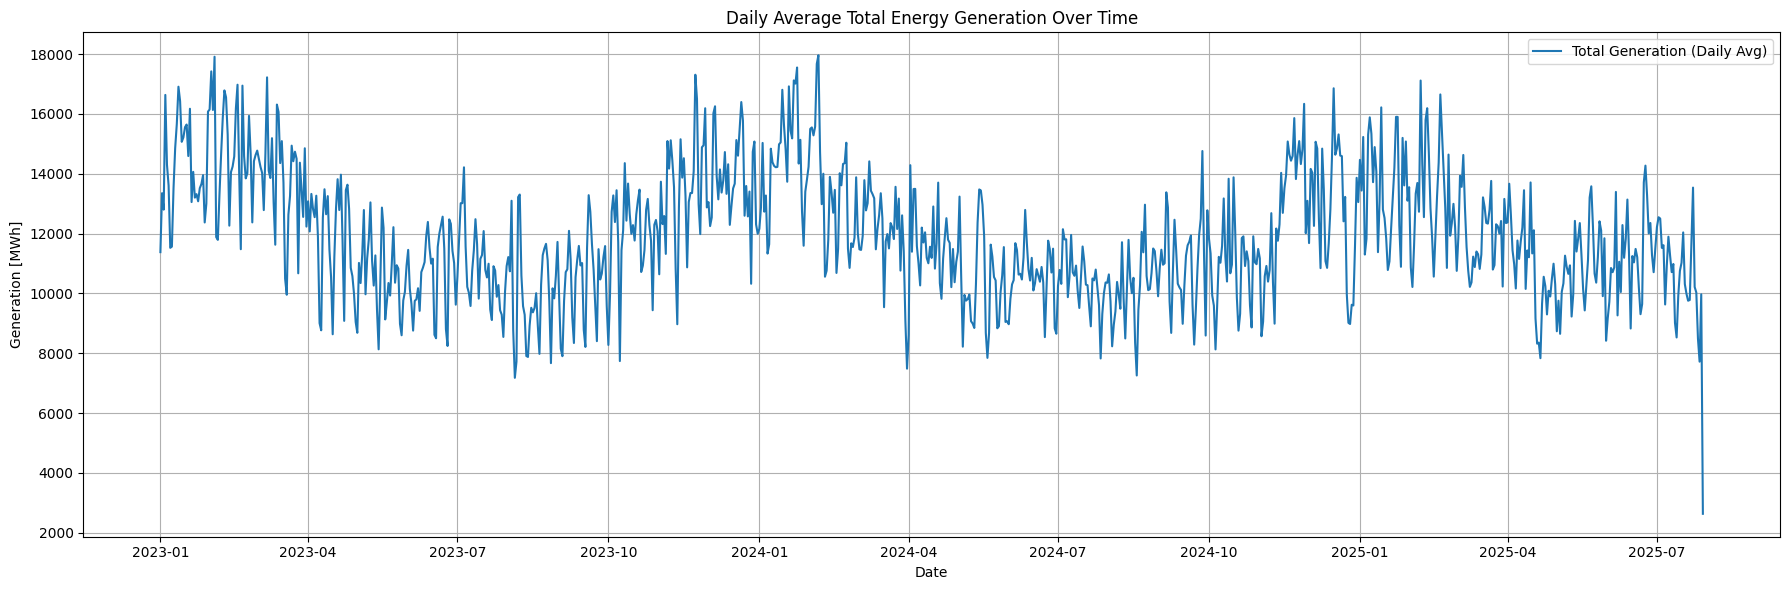

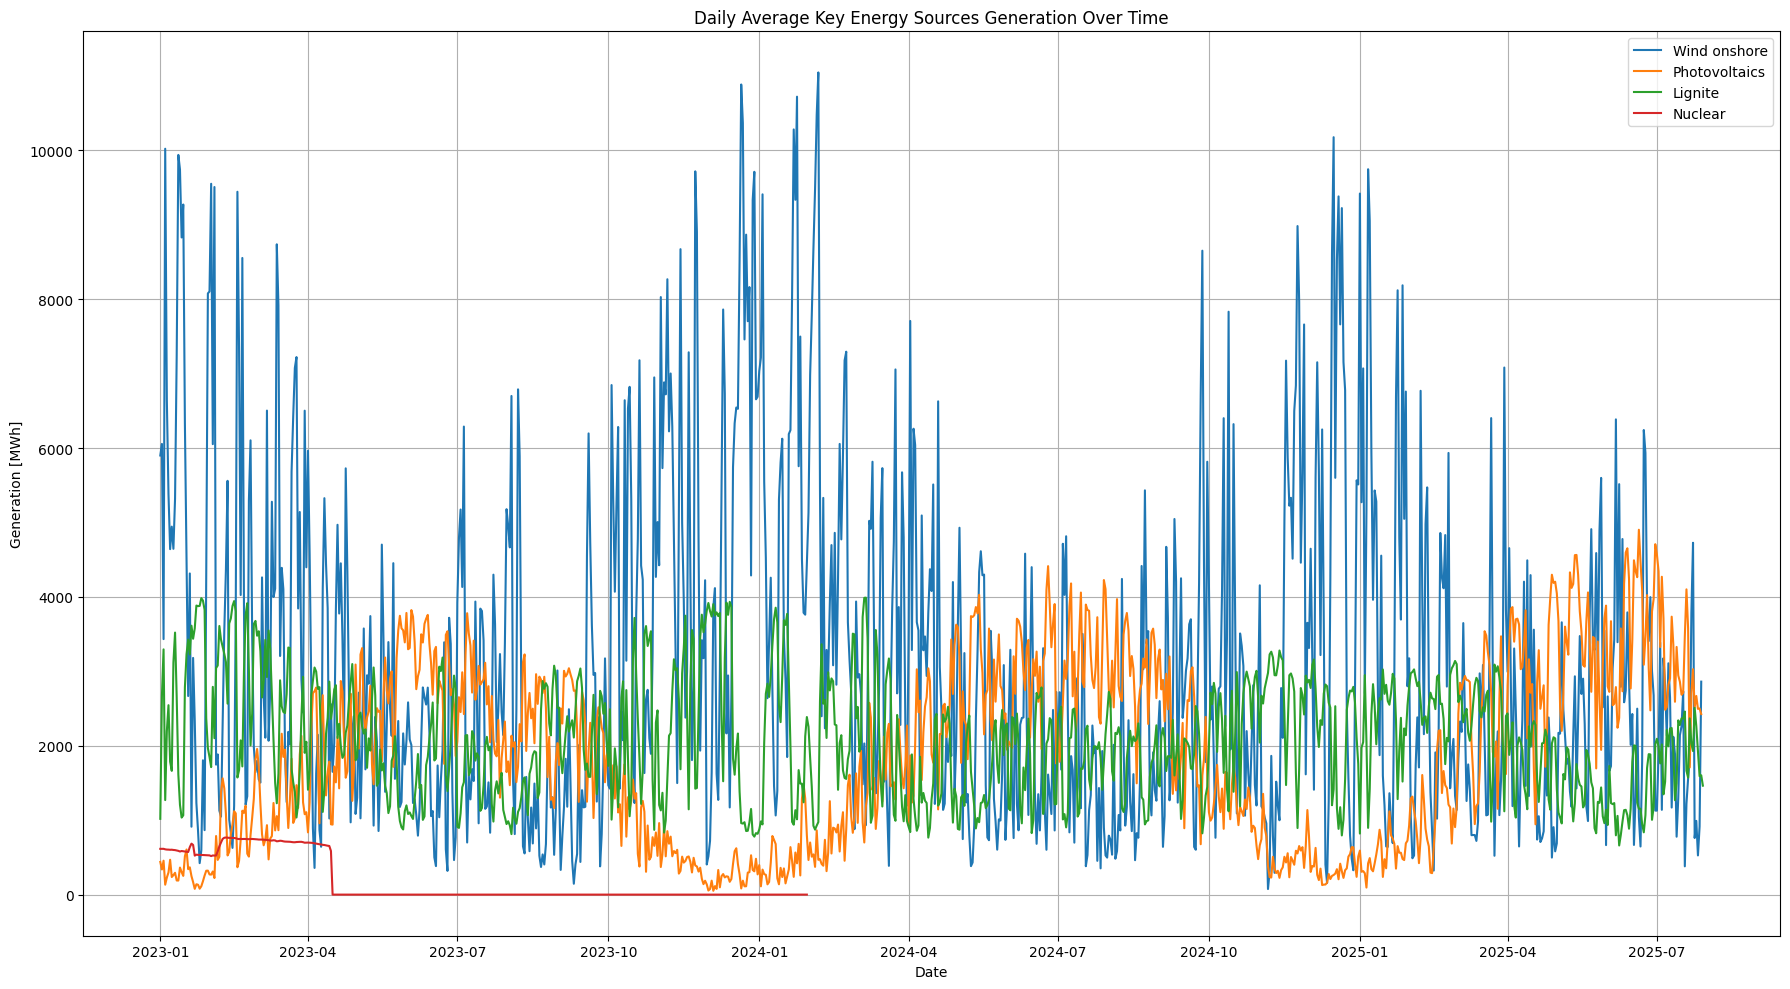

In [13]:
# --- Data Resampling to Daily Averages ---
# Sets 'Start date' as the DataFrame index for time-series operations.
df_resampled_daily = df.set_index('Start date')

# Defines columns to be resampled, excluding the temporary 'Total Generation' for recalculation.
columns_to_resample = [col for col in df.columns if 'MWh' in col and col != 'Total Generation [MWh]']

# Resamples the data to a daily frequency, calculating the mean for each day.
df_daily_avg = df_resampled_daily[columns_to_resample].resample('D').mean()

# Recalculates 'Total Generation' for the daily averaged DataFrame.
df_daily_avg['Total Generation [MWh]'] = df_daily_avg[generation_columns].sum(axis=1)

print("\nDaily Averaged DataFrame Head:")
print(df_daily_avg.head())
print("\nDaily Averaged DataFrame Info:")
df_daily_avg.info()

# Plots the daily average total energy generation trend over time.
plt.figure(figsize=(18, 6))
plt.plot(df_daily_avg.index, df_daily_avg['Total Generation [MWh]'], label='Total Generation (Daily Avg)')
plt.title('Daily Average Total Energy Generation Over Time')
plt.xlabel('Date')
plt.ylabel('Generation [MWh]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Visualizes daily average trends for selected key individual energy sources.
plt.figure(figsize=(18, 10))
for col in key_sources:
    plt.plot(df_daily_avg.index, df_daily_avg[col], label=col.replace(' [MWh] Original resolutions', ''))
plt.title('Daily Average Key Energy Sources Generation Over Time')
plt.xlabel('Date')
plt.ylabel('Generation [MWh]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

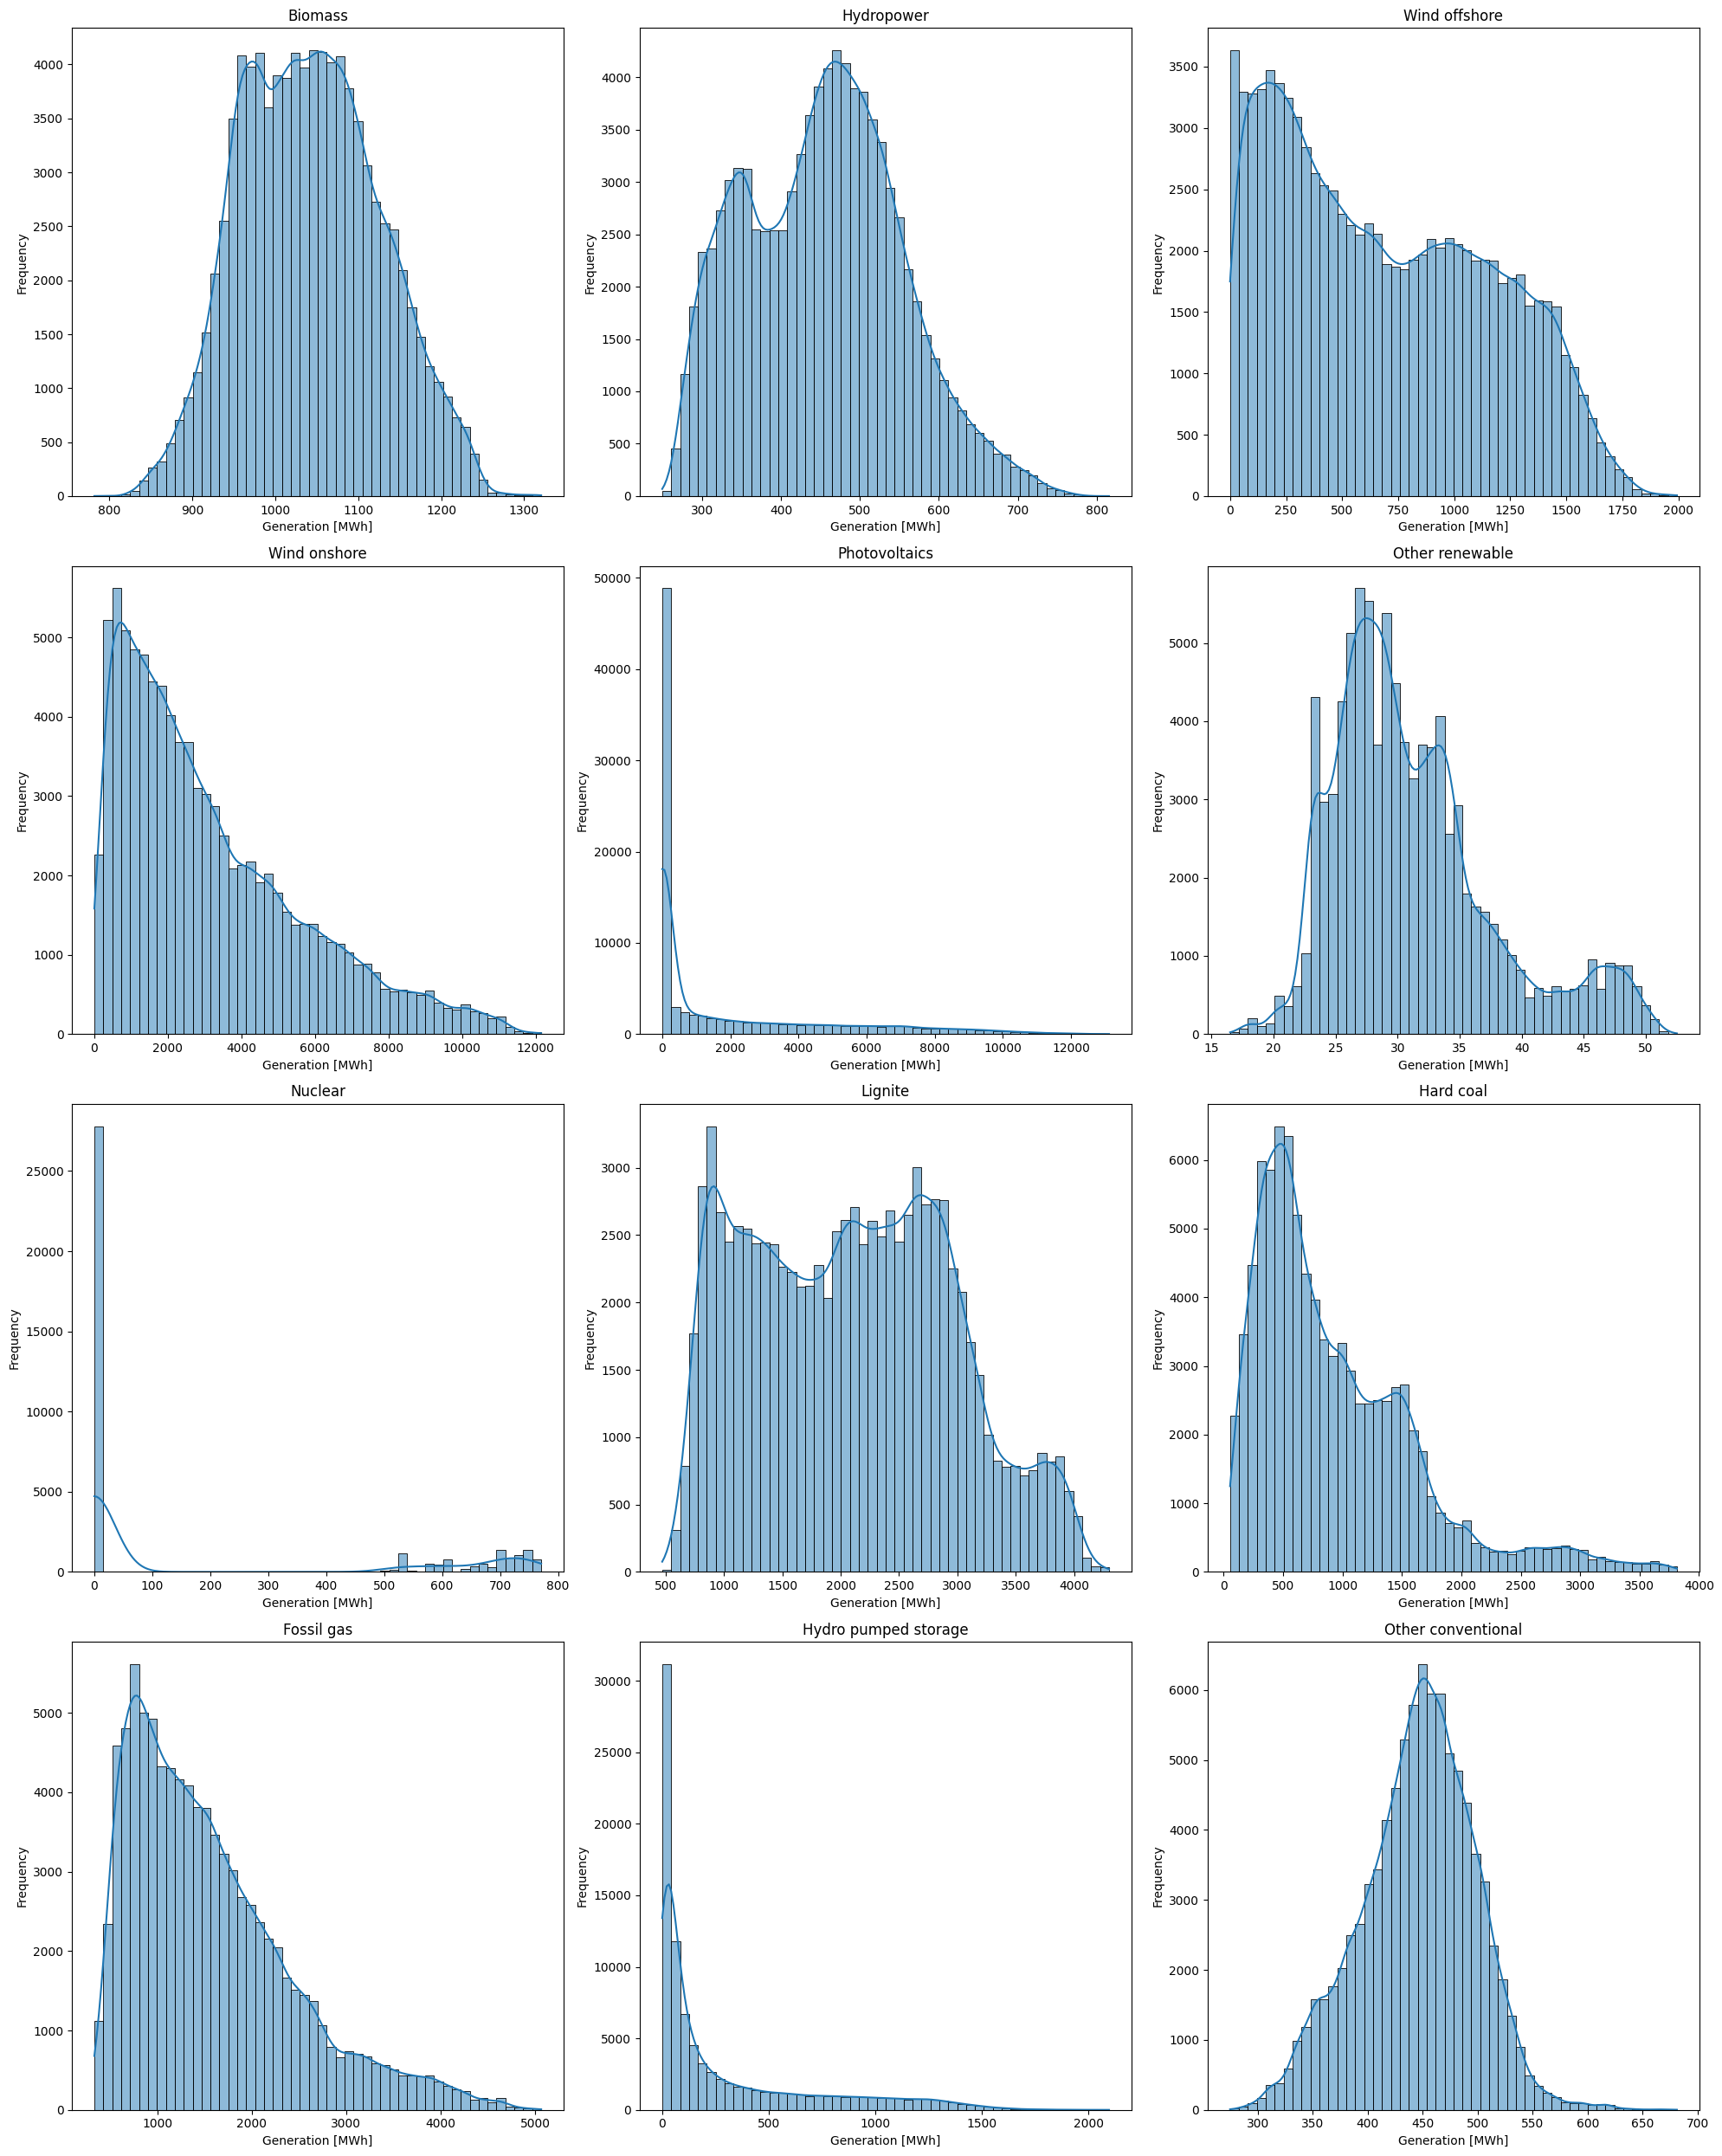


Descriptive statistics for all generation columns to complement histograms:
       Biomass [MWh] Original resolutions  \
count                        90232.000000   
mean                          1042.763413   
std                             83.226098   
min                            782.250000   
25%                            978.000000   
50%                           1040.000000   
75%                           1101.250000   
max                           1320.500000   

       Hydropower [MWh] Original resolutions  \
count                           90232.000000   
mean                              453.928689   
std                                98.585096   
min                               249.750000   
25%                               373.500000   
50%                               456.500000   
75%                               520.750000   
max                               815.500000   

       Wind offshore [MWh] Original resolutions  \
count                            

In [14]:
# --- Exploratory Data Analysis: Generation Source Distributions ---
# Defines the list of numerical generation columns for which to plot histograms.
generation_columns_for_hist = [
    "Biomass [MWh] Original resolutions",
    "Hydropower [MWh] Original resolutions",
    "Wind offshore [MWh] Original resolutions",
    "Wind onshore [MWh] Original resolutions",
    "Photovoltaics [MWh] Original resolutions",
    "Other renewable [MWh] Original resolutions",
    "Nuclear [MWh] Original resolutions",
    "Lignite [MWh] Original resolutions",
    "Hard coal [MWh] Original resolutions",
    "Fossil gas [MWh] Original resolutions",
    "Hydro pumped storage [MWh] Original resolutions",
    "Other conventional [MWh] Original resolutions"
]

# Creates and displays histograms for each specified generation source, showing their distribution.
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(generation_columns_for_hist):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(col.replace(' [MWh] Original resolutions', ''))
    axes[i].set_xlabel('Generation [MWh]')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Prints descriptive statistics for all generation columns to complement the histograms.
print("\nDescriptive statistics for all generation columns to complement histograms:")
print(df[generation_columns_for_hist].describe())

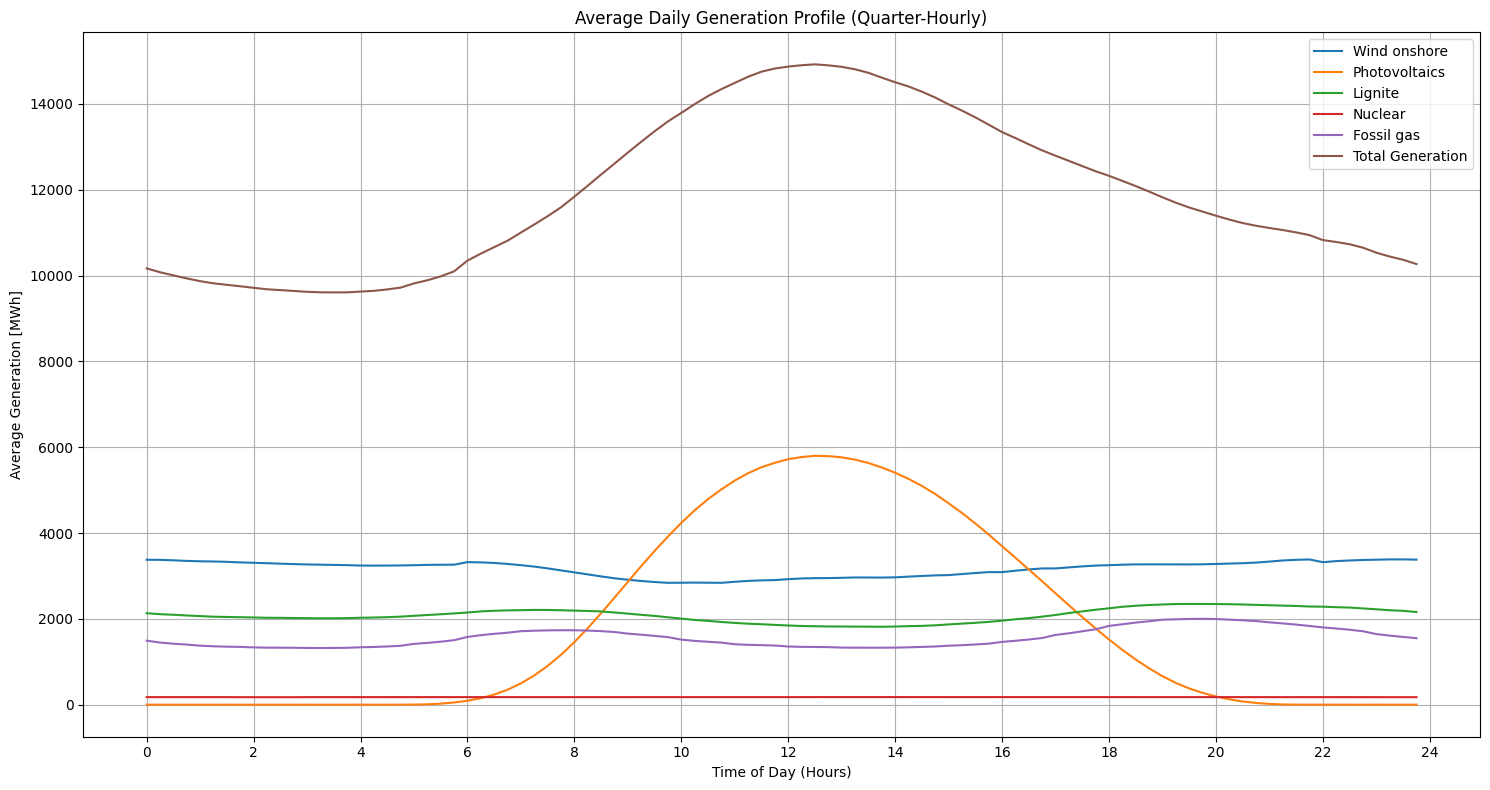

In [15]:
# --- Exploratory Data Analysis: Average Daily Profiles ---
# Extracts 'Hour' and 'Minute' from 'Start date' and combines them into 'Time_of_Day'.
df['Hour'] = df['Start date'].dt.hour
df['Minute'] = df['Start date'].dt.minute
df['Time_of_Day'] = df['Hour'] + df['Minute'] / 60

# Defines key generation columns for daily profile analysis.
profile_columns = [
    "Wind onshore [MWh] Original resolutions",
    "Photovoltaics [MWh] Original resolutions",
    "Lignite [MWh] Original resolutions",
    "Nuclear [MWh] Original resolutions",
    "Fossil gas [MWh] Original resolutions",
    "Total Generation [MWh]"
]

# Calculates the average generation for each quarter-hour of the day.
daily_profile = df.groupby('Time_of_Day')[profile_columns].mean()

# Plots the average daily generation profile for selected sources.
plt.figure(figsize=(15, 8))
for col in profile_columns:
    plt.plot(daily_profile.index, daily_profile[col], label=col.replace(' [MWh] Original resolutions', '').replace(' [MWh]', ''))

plt.title('Average Daily Generation Profile (Quarter-Hourly)')
plt.xlabel('Time of Day (Hours)')
plt.ylabel('Average Generation [MWh]')
plt.xticks(range(0, 25, 2))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Drops the temporary time-related columns if they are no longer needed.
df.drop(columns=['Hour', 'Minute', 'Time_of_Day'], errors='ignore', inplace=True)

<Figure size 1200x700 with 0 Axes>

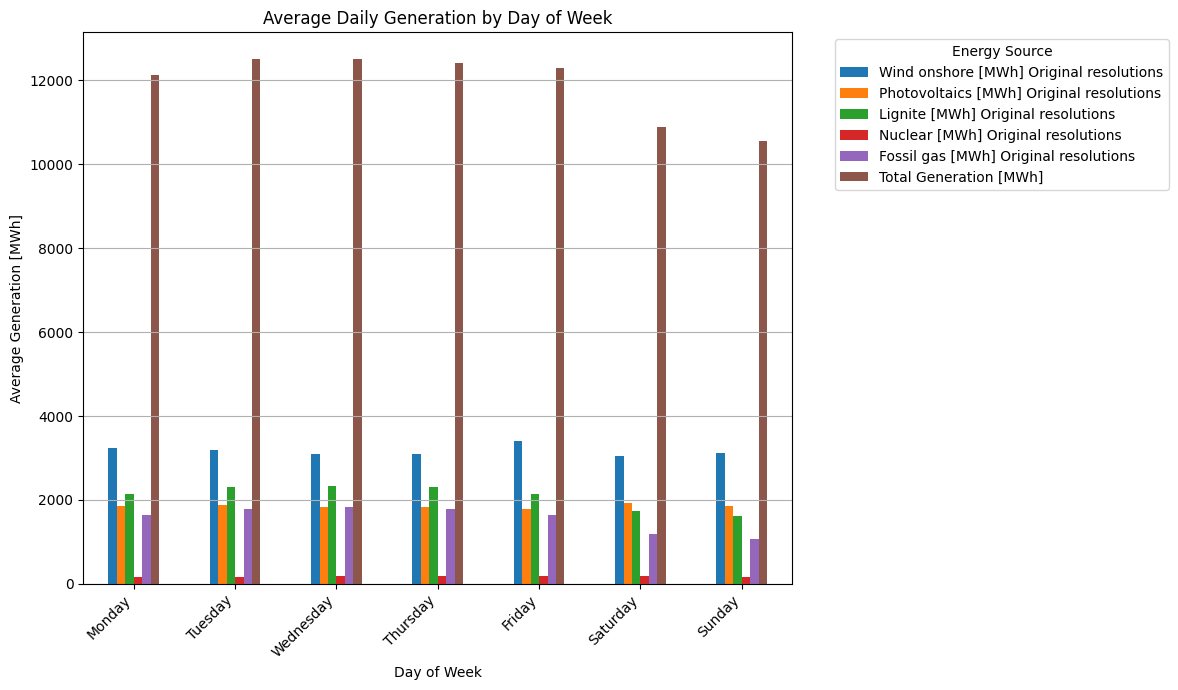

In [16]:
# --- Exploratory Data Analysis: Average Weekly Patterns ---
# Extracts the day of the week (Monday=0, Sunday=6) from the 'Start date'.
df['Day_of_Week'] = df['Start date'].dt.dayofweek

# Calculates the average daily generation per day of the week using the daily averaged data.
weekly_pattern = df_daily_avg.groupby(df_daily_avg.index.dayofweek)[profile_columns].mean()

# Renames the index for better readability in plots (e.g., 0 to 'Monday').
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pattern.index = day_names

# Plots the average daily generation by day of the week for selected sources.
plt.figure(figsize=(12, 7))
weekly_pattern.plot(kind='bar', figsize=(12, 7))
plt.title('Average Daily Generation by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Generation [MWh]')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.legend(title='Energy Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Drops the temporary 'Day_of_Week' column if no longer required in the main DataFrame.
df.drop(columns=['Day_of_Week'], errors='ignore', inplace=True)
# If 'Day_of_Week' was also added to df_daily_avg explicitly, consider dropping it there too.

<Figure size 1200x700 with 0 Axes>

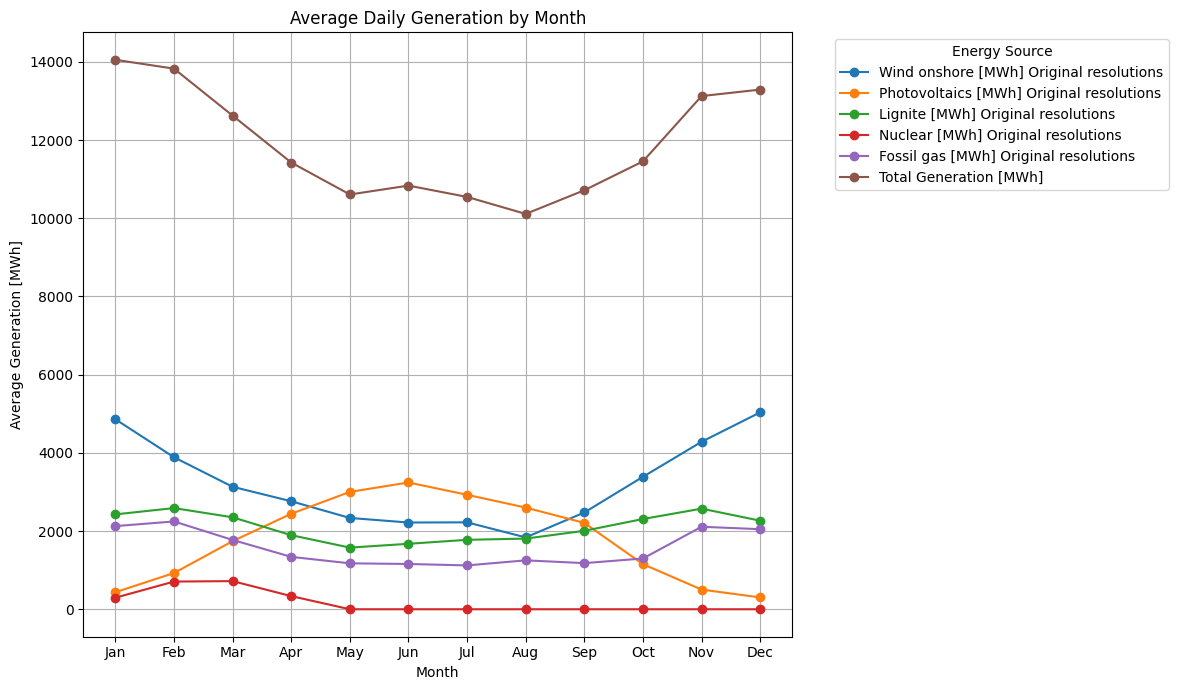

In [17]:
# --- Exploratory Data Analysis: Average Monthly Patterns ---
# Extracts the month of the year from the daily averaged DataFrame's index.
df_daily_avg['Month'] = df_daily_avg.index.month

# Calculates the average daily generation per month for selected sources.
monthly_pattern = df_daily_avg.groupby('Month')[profile_columns].mean()

# Plots the average daily generation by month.
plt.figure(figsize=(12, 7))
monthly_pattern.plot(kind='line', marker='o', figsize=(12, 7))
plt.title('Average Daily Generation by Month')
plt.xlabel('Month')
plt.ylabel('Average Generation [MWh]')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Energy Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Drops the temporary 'Month' column from the daily averaged DataFrame.
df_daily_avg.drop(columns=['Month'], errors='ignore', inplace=True)

In [18]:
import numpy as np

# --- Feature Engineering: Time-Based Features ---
# Extracts various temporal features from the 'Start date' column.

# Basic time components: Hour, Day of Week, Day of Year, Month, Quarter, Year.
df['hour_of_day'] = df['Start date'].dt.hour
df['day_of_week'] = df['Start date'].dt.dayofweek
df['day_of_year'] = df['Start date'].dt.dayofyear
df['month_of_year'] = df['Start date'].dt.month
df['quarter_of_year'] = df['Start date'].dt.quarter
df['year'] = df['Start date'].dt.year

# Binary indicator for weekend.
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Creates cyclical features (sine and cosine transformations) for 'hour_of_day'.
# This helps the model understand the continuous nature of time cycles.
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

# Creates cyclical features for 'day_of_year' to capture yearly seasonality.
days_in_year = 365.25 # Accounts for leap years
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / days_in_year)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / days_in_year)

# Displays the head of the DataFrame to show the newly added features.
print("\nDataFrame head with new time-based features:")
print(df[['Start date', 'hour_of_day', 'day_of_week', 'day_of_year',
          'month_of_year', 'quarter_of_year', 'is_weekend',
          'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos']].head())
print(f"\nDataFrame shape after feature engineering: {df.shape}")


DataFrame head with new time-based features:
           Start date  hour_of_day  day_of_week  day_of_year  month_of_year  \
0 2023-01-01 00:00:00            0            6            1              1   
1 2023-01-01 00:15:00            0            6            1              1   
2 2023-01-01 00:30:00            0            6            1              1   
3 2023-01-01 00:45:00            0            6            1              1   
4 2023-01-01 01:00:00            1            6            1              1   

   quarter_of_year  is_weekend  hour_sin  hour_cos  day_of_year_sin  \
0                1           1  0.000000  1.000000         0.017202   
1                1           1  0.000000  1.000000         0.017202   
2                1           1  0.000000  1.000000         0.017202   
3                1           1  0.000000  1.000000         0.017202   
4                1           1  0.258819  0.965926         0.017202   

   day_of_year_cos  
0         0.999852  
1         

In [19]:
# --- Data Splitting: Train, Validation, Test Sets ---
# Ensures the DataFrame index is a sorted DatetimeIndex for chronological splitting.
if not isinstance(df.index, pd.DatetimeIndex):
    df.set_index('Start date', inplace=True)
    df.sort_index(inplace=True)

# Defines the chronological split points for the dataset.
train_end_date = '2023-12-31 23:59:00'
val_end_date = '2024-12-31 23:59:00'

# Creates training, validation, and test DataFrames based on the defined date ranges.
train_df = df.loc[:train_end_date]
val_df = df.loc['2024-01-01 00:00:00':val_end_date]
test_df = df.loc['2025-01-01 00:00:00':]

# Prints the shape and date range for each dataset split for verification.
print(f"\nTraining set shape: {train_df.shape}")
print(f"Training set date range: {train_df.index.min()} to {train_df.index.max()}")

print(f"\nValidation set shape: {val_df.shape}")
print(f"Validation set date range: {val_df.index.min()} to {val_df.index.max()}")

print(f"\nTest set shape: {test_df.shape}")
print(f"Test set date range: {test_df.index.min()} to {test_df.index.max()}")


Training set shape: (35039, 25)
Training set date range: 2023-01-01 00:00:00 to 2023-12-31 23:45:00

Validation set shape: (35135, 25)
Validation set date range: 2024-01-01 00:00:00 to 2024-12-31 23:45:00

Test set shape: (20155, 25)
Test set date range: 2025-01-01 00:00:00 to 2025-07-29 23:45:00


In [20]:
# --- Feature and Target Definition ---
# Defines the target variable for the forecasting model.
target_variable = 'Total Generation [MWh]'

# Selects all columns as features (X) except the 'End date' and the target variable itself.
features = [col for col in df.columns if col not in ['End date', target_variable]]

# Ensures 'Start date' is not included in features as it is set as the DataFrame index.
features = [f for f in features if f != 'Start date']

# Separates features (X) and target (Y) for the training, validation, and test datasets.
X_train = train_df[features]
y_train = train_df[target_variable]

X_val = val_df[features]
y_val = val_df[target_variable]

X_test = test_df[features]
y_test = test_df[target_variable]

# Prints the shapes of the resulting datasets for verification.
print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Displays the head of the feature and target sets for inspection.
print("\nExample of X_train features:")
print(X_train.head())

print("\nExample of y_train target:")
print(y_train.head())


X_train shape: (35039, 23), y_train shape: (35039,)
X_val shape: (35135, 23), y_val shape: (35135,)
X_test shape: (20155, 23), y_test shape: (20155,)

Example of X_train features:
                     Biomass [MWh] Original resolutions  \
Start date                                                
2023-01-01 00:00:00                             1006.25   
2023-01-01 00:15:00                             1003.50   
2023-01-01 00:30:00                             1003.00   
2023-01-01 00:45:00                             1001.50   
2023-01-01 01:00:00                              997.50   

                     Hydropower [MWh] Original resolutions  \
Start date                                                   
2023-01-01 00:00:00                                 319.75   
2023-01-01 00:15:00                                 317.25   
2023-01-01 00:30:00                                 317.00   
2023-01-01 00:45:00                                 321.25   
2023-01-01 01:00:00              

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index



Feature names cleaned. Example of X_train features after cleaning:
                     Biomass_MWh_Original_resolutions  \
Start date                                              
2023-01-01 00:00:00                           1006.25   
2023-01-01 00:15:00                           1003.50   
2023-01-01 00:30:00                           1003.00   
2023-01-01 00:45:00                           1001.50   
2023-01-01 01:00:00                            997.50   

                     Hydropower_MWh_Original_resolutions  \
Start date                                                 
2023-01-01 00:00:00                               319.75   
2023-01-01 00:15:00                               317.25   
2023-01-01 00:30:00                               317.00   
2023-01-01 00:45:00                               321.25   
2023-01-01 01:00:00                               314.75   

                     Wind_offshore_MWh_Original_resolutions  \
Start date                                      

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):



XGBoost Model Training Complete.
Best iteration (number of trees): 76

--- Model Evaluation ---
Validation MAE: 625.28 MWh
Validation RMSE: 838.75 MWh

Test MAE: 723.63 MWh
Test RMSE: 1420.04 MWh


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/xgboost/data.py:262: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  elif isinstance(data.columns, (pd.Int64Index, pd.RangeIndex)):


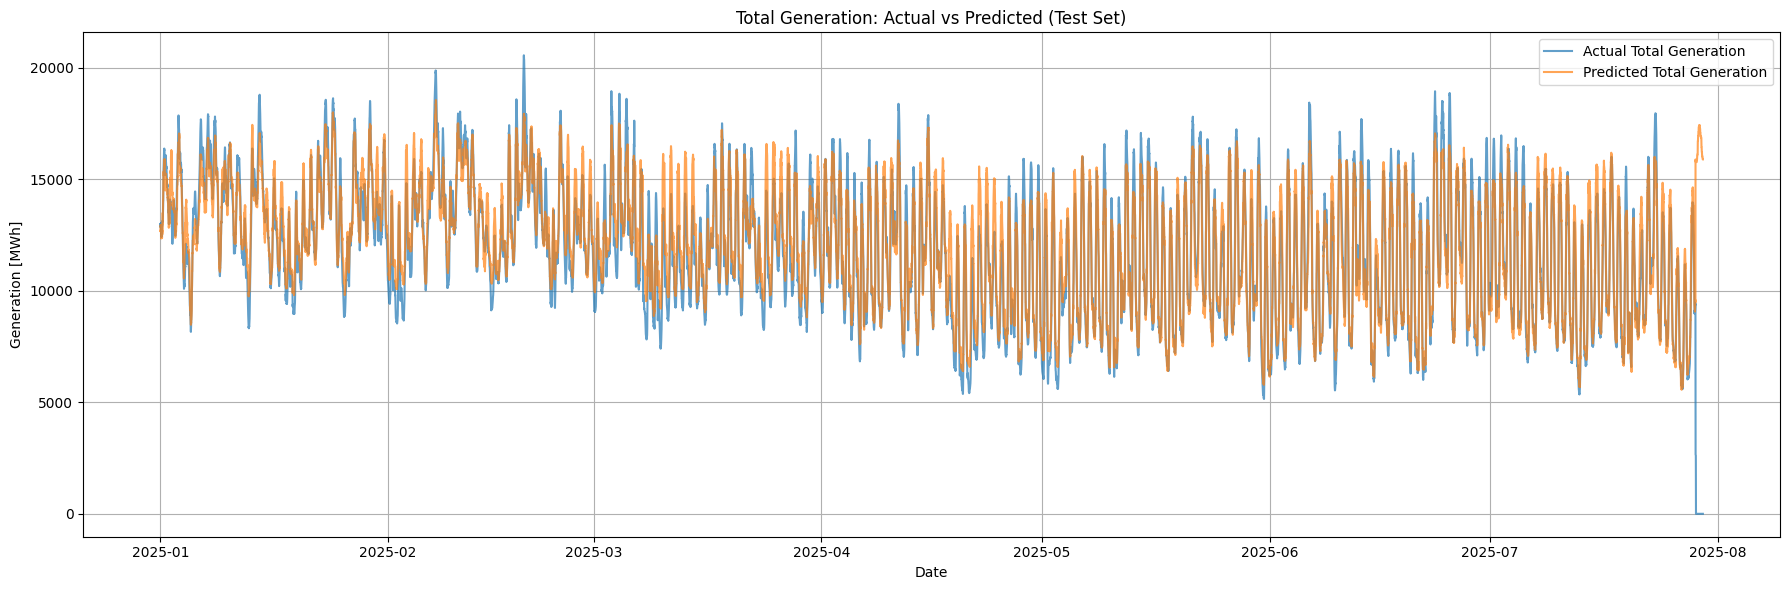


--- Feature Importance ---


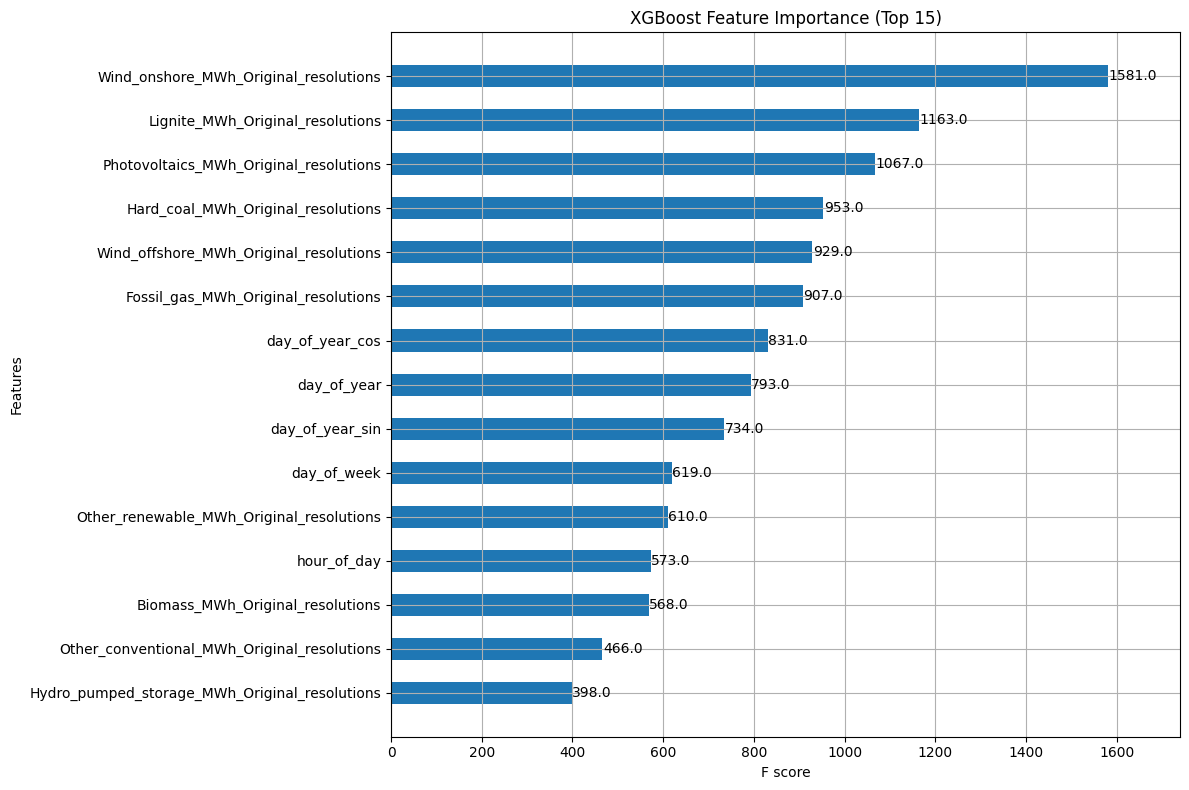

In [21]:
import re
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

# --- Feature Name Cleaning ---
# Cleans feature names to be compatible with XGBoost, replacing special characters and spaces.
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[\[\]<>]', '', col)
        new_col = new_col.replace(' ', '_')
        new_col = new_col.replace('.', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Applies the cleaning function to the feature sets (X_train, X_val, X_test).
X_train = clean_col_names(X_train.copy())
X_val = clean_col_names(X_val.copy())
X_test = clean_col_names(X_test.copy())

print("\nFeature names cleaned. Example of X_train features after cleaning:")
print(X_train.head())

# --- Model Training: XGBoost Regressor ---
# Suppresses XGBoost-specific warnings for cleaner output.
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

# Initializes the XGBoost Regressor model with optimized parameters.
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    objective='reg:squarederror'
)

# Trains the model using the training data and validates with early stopping on the validation set.
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          early_stopping_rounds=50,
          verbose=False)

print("\nXGBoost Model Training Complete.")
print(f"Best iteration (number of trees): {model.best_iteration}")

# --- Model Evaluation ---
# Generates predictions on the validation and test sets.
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")

# Calculates and prints Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for validation set.
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Validation MAE: {mae_val:.2f} MWh")
print(f"Validation RMSE: {rmse_val:.2f} MWh")

# Calculates and prints MAE and RMSE for the test set.
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"\nTest MAE: {mae_test:.2f} MWh")
print(f"Test RMSE: {rmse_test:.2f} MWh")

# --- Visualization of Results ---
# Plots actual vs. predicted total generation for the test set to visualize model performance.
plt.figure(figsize=(18, 6))
plt.plot(y_test.index, y_test, label='Actual Total Generation', alpha=0.7)
plt.plot(y_test.index, y_test_pred, label='Predicted Total Generation', alpha=0.7)
plt.title('Total Generation: Actual vs Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Generation [MWh]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plots the top 15 most important features as determined by the XGBoost model.
print("\n--- Feature Importance ---")
fig, ax = plt.subplots(figsize=(12, 8))
xgb.plot_importance(model, max_num_features=15, height=0.5, ax=ax)
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

Mean Residual: -274.19
Standard Deviation of Residuals: 1393.35


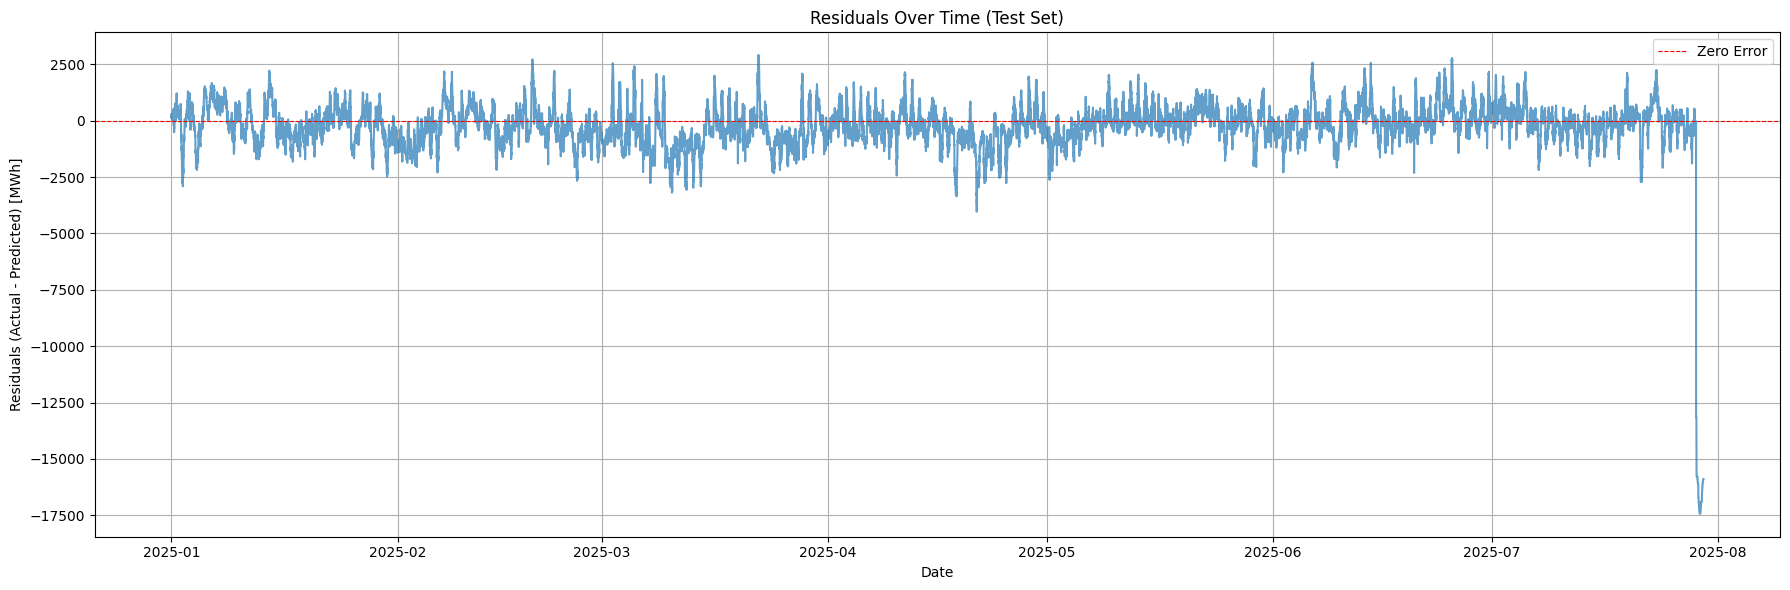

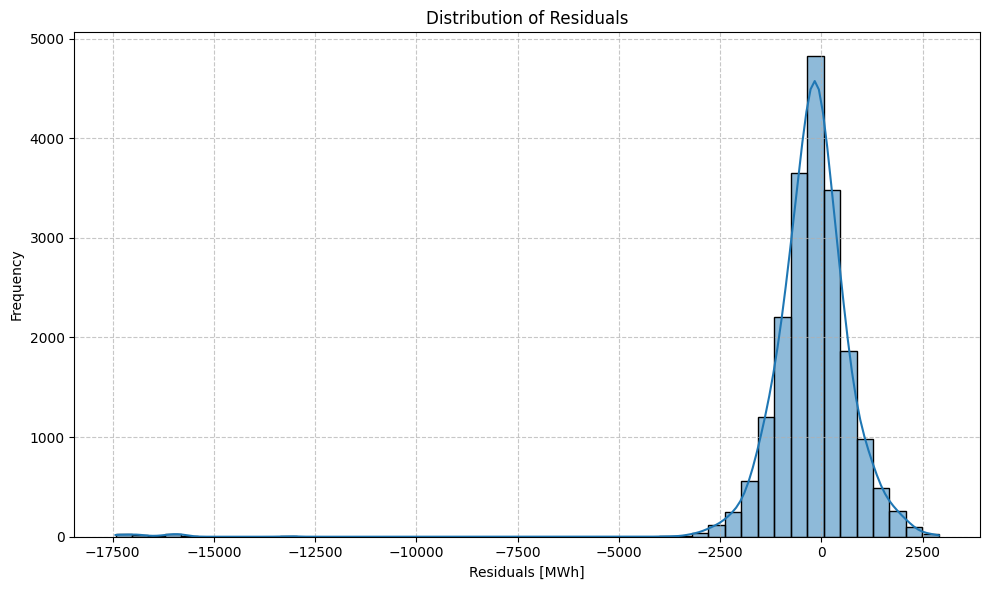

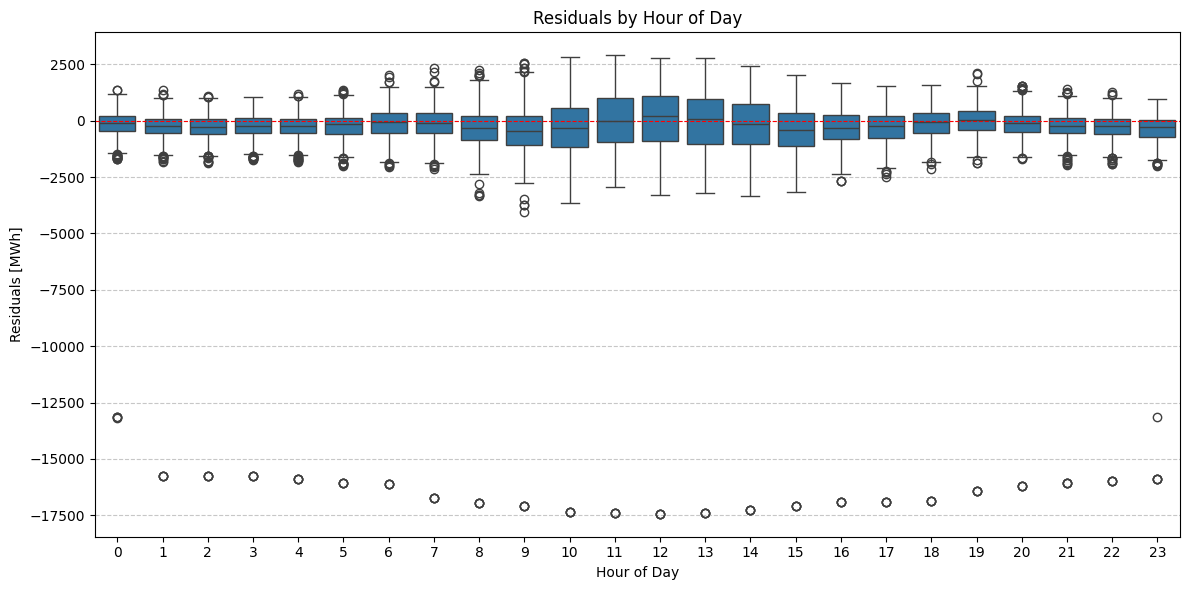

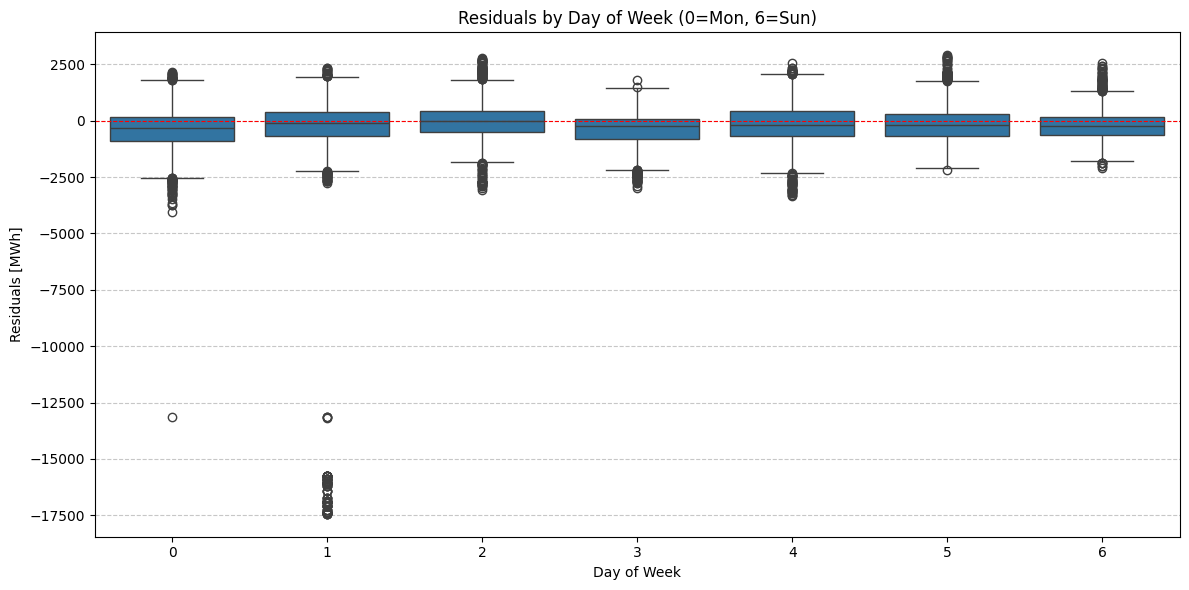

In [22]:
# --- Residual Analysis ---
# Calculates prediction residuals (Actual - Predicted values) for the test set.
residuals = y_test - y_test_pred
print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Standard Deviation of Residuals: {residuals.std():.2f}")

# Creates a DataFrame for residuals, incorporating time components for detailed analysis.
residuals_df = pd.DataFrame({'Residuals': residuals})
residuals_df['hour_of_day'] = residuals_df.index.hour
residuals_df['day_of_week'] = residuals_df.index.dayofweek
residuals_df['month_of_year'] = residuals_df.index.month
residuals_df['year'] = residuals_df.index.year

# --- Visualization of Residuals ---

# Plots residuals over time to identify any temporal patterns in errors.
plt.figure(figsize=(18, 6))
plt.plot(residuals_df.index, residuals_df['Residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero Error')
plt.title('Residuals Over Time (Test Set)')
plt.xlabel('Date')
plt.ylabel('Residuals (Actual - Predicted) [MWh]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Displays the distribution of residuals using a histogram and KDE plot.
plt.figure(figsize=(10, 6))
sns.histplot(residuals_df['Residuals'], bins=50, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals [MWh]')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualizes residual patterns by hour of day using box plots.
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour_of_day', y='Residuals', data=residuals_df)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('Residuals by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Residuals [MWh]')
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()

# Visualizes residual patterns by day of week using box plots.
plt.figure(figsize=(12, 6))
sns.boxplot(x='day_of_week', y='Residuals', data=residuals_df)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('Residuals by Day of Week (0=Mon, 6=Sun)')
plt.xlabel('Day of Week')
plt.ylabel('Residuals [MWh]')
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer # Import SimpleImputer

# --- Benchmarking Against Simple Baseline Models ---

# 1. Naive Forecast (Lag-1)
# Implements a simple naive forecast by shifting the test target by one period.
y_test_naive_pred = y_test.shift(1)
y_test_naive_pred.dropna(inplace=True)
y_test_filtered_for_naive = y_test.loc[y_test_naive_pred.index]

# Calculates Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for the Naive forecast.
mae_naive = mean_absolute_error(y_test_filtered_for_naive, y_test_naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_test_filtered_for_naive, y_test_naive_pred))

print("\nNaive Forecast (Lag-1) Performance:")
print(f"  MAE: {mae_naive:.2f} MWh")
print(f"  RMSE: {rmse_naive:.2f} MWh")

# 2. Simple Linear Regression Model
# Initializes a Linear Regression model.
lr_model = LinearRegression(n_jobs=-1)

# Handles missing values using SimpleImputer, filling NaNs with the mean from the training set.
imputer = SimpleImputer(strategy='mean')
X_train_lr_imputed = imputer.fit_transform(X_train)
X_test_lr_imputed = imputer.transform(X_test)

# Converts imputed arrays back to DataFrames with original column names and index.
X_train_lr_imputed = pd.DataFrame(X_train_lr_imputed, columns=X_train.columns, index=X_train.index)
X_test_lr_imputed = pd.DataFrame(X_test_lr_imputed, columns=X_test.columns, index=X_test.index)

# Uses the original y_train and y_test as they are assumed to be clean.
y_train_lr = y_train
y_test_lr = y_test

# Fits the Linear Regression model on the imputed training data.
lr_model.fit(X_train_lr_imputed, y_train_lr)

# Makes predictions on the imputed test set.
y_test_lr_pred = lr_model.predict(X_test_lr_imputed)

# Calculates MAE and RMSE for the Linear Regression model.
mae_lr = mean_absolute_error(y_test_lr, y_test_lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_test_lr_pred))

print("\nLinear Regression Model Performance:")
print(f"  MAE: {mae_lr:.2f} MWh")
print(f"  RMSE: {rmse_lr:.2f} MWh")

# --- Performance Comparison ---
# Displays a comparative table of performance metrics for all evaluated models.
print("\n--- Performance Comparison (Test Set) ---")
print(f"{'Model':<20} {'MAE':<10} {'RMSE':<10}")
print(f"{'XGBoost':<20} {mae_test:.2f}{' MWh':<5} {rmse_test:.2f}{' MWh':<5}")
print(f"{'Naive Forecast':<20} {mae_naive:.2f}{' MWh':<5} {rmse_naive:.2f}{' MWh':<5}")
print(f"{'Linear Regression':<20} {mae_lr:.2f}{' MWh':<5} {rmse_lr:.2f}{' MWh':<5}")


Naive Forecast (Lag-1) Performance:
  MAE: 149.99 MWh
  RMSE: 206.47 MWh

Linear Regression Model Performance:
  MAE: 249.36 MWh
  RMSE: 857.99 MWh

--- Performance Comparison (Test Set) ---
Model                MAE        RMSE      
XGBoost              723.63 MWh  1420.04 MWh 
Naive Forecast       149.99 MWh  206.47 MWh 
Linear Regression    249.36 MWh  857.99 MWh 
